Github repository is here: https://github.com/ong8181/DASC3240

In [1]:
import pandas as pd
pd.__version__

'2.1.4'

# Scatter plot – Assignments

## Reference and datasets
- https://github.com/ong8181/DASC3240/blob/main/data/d_nonlinear.csv

# Assignments

1. Linear regression: Load `d_nonlinser.csv` and draw a scatter plot of `X` and `Y`. Then, add a linear regression line without confidence intervals.
2. LOWESS: Load `d_nonlinser.csv` and draw a scatter plot of `X` and `Y`. Then, add a LOWESS fitting curve without confidence intervals.
3. Visualize the effect of the parameter `frac` on LOWESS.

### [Optional]
4. In Task 3, you generate 6 plots. How can we choose the most appropriate LOWESS curve? Please explain your thoughts with supporting evidence (e.g., book, url, and/or scientific manuscript). You can use any AI tool(s), but note that such tool(s) often provide wrong reference(s).

# Declaration
<font color="darkred">Please answer the following questions.</font>  
Do you use AI-based assistant tool(s) (such as ChatGPT or Copilot) to complete the assignments?
- [ ] Yes
- [ ] No

If "Yes", please specify which task(s) you used the tool(s):
```
XXXX
```

# 1. Linear regression: Load `d_nonlinser.csv` and draw a scatter plot of `X` and `Y`. Then, add a linear regression line without confidence intervals.

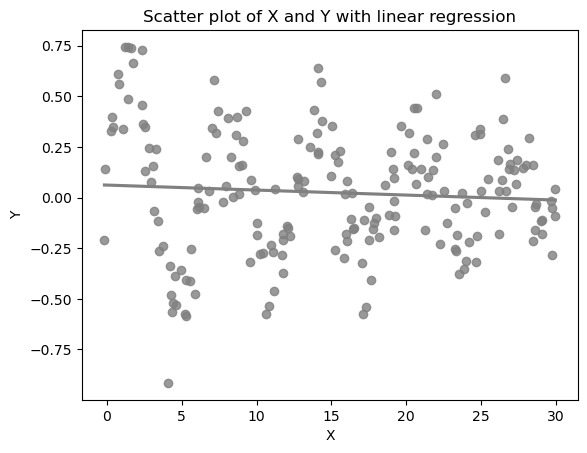

In [1]:
### Your Python code is here
### XXXXX

# Import libraries
import pandas as pd
import numpy as np # For regression line
import matplotlib.pyplot as plt
import seaborn as sns

# Load custom data
d = pd.read_csv('data/d_nonlinear.csv')

# Draw scatterplot and linear regression
ax1 = sns.regplot(x = d['x'], y = d['y'], fit_reg = True, color = 'gray', ci = False)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('Scatter plot of X and Y with linear regression');

## 2. LOWESS: Load `d_nonlinser.csv` and draw a scatter plot of `X` and `Y`. Then, add a LOWESS fitting curve without confidence intervals.

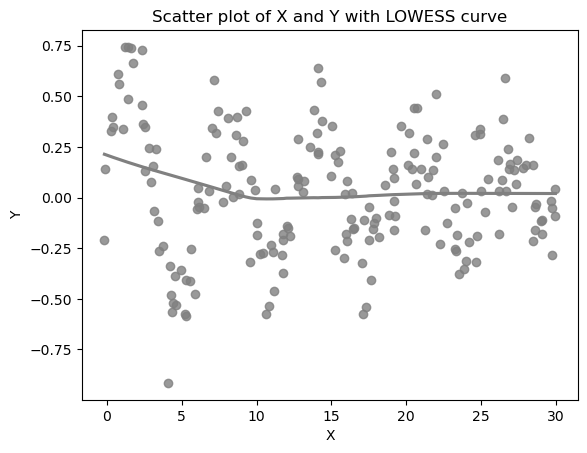

In [2]:
### Your Python code is here
### XXXXX

ax2 = sns.regplot(x = d['x'], y = d['y'], lowess = True, color = 'gray')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Scatter plot of X and Y with LOWESS curve');

## 3. Visualize the effect of the parameter `frac` on LOWESS  

As in Challanges in L09, `seaborn` uses `statsmodels` package to draw LOWESS. You can change detailed parameters to draw LOESS with `statmodels`. Please change the window size of LOWESS using the `frac` option in the `statmodels.nonparametric.lowess` and visualize how the LOWESS curve changes. <font color="darkred">**Please follow the detailed instructions below**</font>:

1. Use `0.01`, `0.02`, `0.05`, `0.1`, `0.2`, and `0.5` as `frac` and generate 6 scatter plots. Each scatter plot must show data points and a LOWESS curve drawn using each `frac` value. Confidence intervals are not necessary.
2. Align the six plots within one large figure using `plt.subplots(nrows = 2, ncols = 3, figsize = (10, 5))` or other equivalent function(s).
3. Add an appropriate title to each plot so that readers can understand which `frac` value was used to draw LOWESS.

You may use `enumerate()` and `for` function to draw multiple figures efficiently (this is not mandatory, but if you use them, you can make the code much shorter).  

Please refer to Challanges in L09 if you are unsure how to draw LOWESS using `statmodels.nonparametric.lowess`. Also, official help document for `statmodels.nonparametric.lowess` is [here](https://www.statsmodels.org/devel/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html).

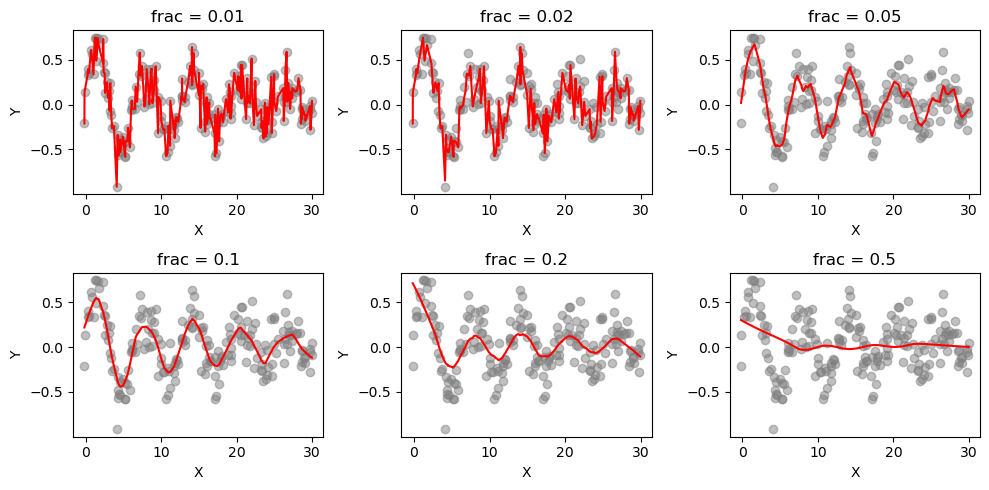

In [3]:
### Your Python code is here
### XXXXX

#import numpy as np                  # Not necessary if loaded previously
#import matplotlib.pyplot as plt     # Not necessary if loaded previously
import statsmodels.api as sm

# Define the values of frac to be used
fracs = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]

# Plot the fit line for each value of frac
fig3, axs3 = plt.subplots(nrows = 2, ncols = 3, figsize = (10, 5))
axs3 = axs3.ravel()

for i, frac in enumerate(fracs):
    sm_df = sm.nonparametric.lowess(exog = d['x'], endog = d['y'], frac = frac)
    axs3[i].scatter(d['x'], d['y'], alpha = 0.5, color = 'gray')
    axs3[i].plot(sm_df[:, 0], sm_df[:, 1], c='r')
    axs3[i].set_xlabel('X')
    axs3[i].set_ylabel('Y')
    axs3[i].set_title(f'frac = {frac}')

plt.tight_layout();

## [Optional]
1. In Task 3, you generated 6 plots. How can we choose the most appropriate LOWESS curve? Please explain your thoughts with supporting evidence (e.g., book, url, and/or scientific manuscript). You can use any AI tool(s), but note that such tool(s) often provide wrong reference(s).

#### Possible answer   
- First, divide the data into the training data and test data. Then, draw a LOWESS curve using the training data and evaluate errors for the test data. This method is called **cross validation**. We may choose the window size that produces the smallest errors.

##### References
- Stone (1974) "Cross-Validatory Choice and Assessment of Statistical Predictions" https://doi.org/10.1111/j.2517-6161.1974.tb00994.x
- Cleveland (1979) Journal of the American Statistical Association, Vol. 74, No. 368 (Dec., 1979), pp. 829-836 http://www.jstor.org/stable/2286407?origin=JSTOR-pdf